# 09 - Public generation-response figures

We present the final-for-analysis 140 judgments through three descriptive figures. Notebook 08 contains the paired tests and complete aggregate tables. This notebook reads only the five public aggregate files committed in `9abcd8f` and verifies their fingerprints before drawing anything. It does not load private questions, answers, notes, response texts or judgment records.

The dissertation assessment expects a clear presentation of results with visuals and interpretation linked to our methodology. We therefore keep correctness, completion, primary errors and the five secondary criteria visible with their denominators. The professor's later comment about the overall system belongs in the discussion, separately from the fixed scoring data.


In [1]:
from __future__ import annotations

import hashlib
import sys
from pathlib import Path
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "results/metrics/generation-evaluation.json").is_file():
    raise FileNotFoundError("Committed aggregate results were not found.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from geotech_rag.generation_result_figures import (
    FOLDER, INPUT_SHA256, load_public_tables, plan_figures, write_figures,
)

RUN_WRITE_PUBLIC_FIGURES = False
tables = load_public_tables(PROJECT_ROOT)
figures = plan_figures(PROJECT_ROOT)
print("Verified public input files:", len(INPUT_SHA256))
print("Tracked result commit: 9abcd8f")
print("Write public figure files:", RUN_WRITE_PUBLIC_FIGURES)


Verified public input files: 5
Tracked result commit: 9abcd8f
Write public figure files: False


## 1. Correctness and completion

We show the number of fully correct answers from all 20 prevalidated questions in each condition. The whiskers give Wilson 95% intervals for correctness on this fixed question set. Completion is separate: a visible answer does not imply a correct answer. The nine responses without visible text all belong to M2 and remain incorrect in the 20-question accuracy denominator. We interpret M3's 20/20 result for this recorded run; its `gpt-6-astra` model name was a mutable alias at generation time.


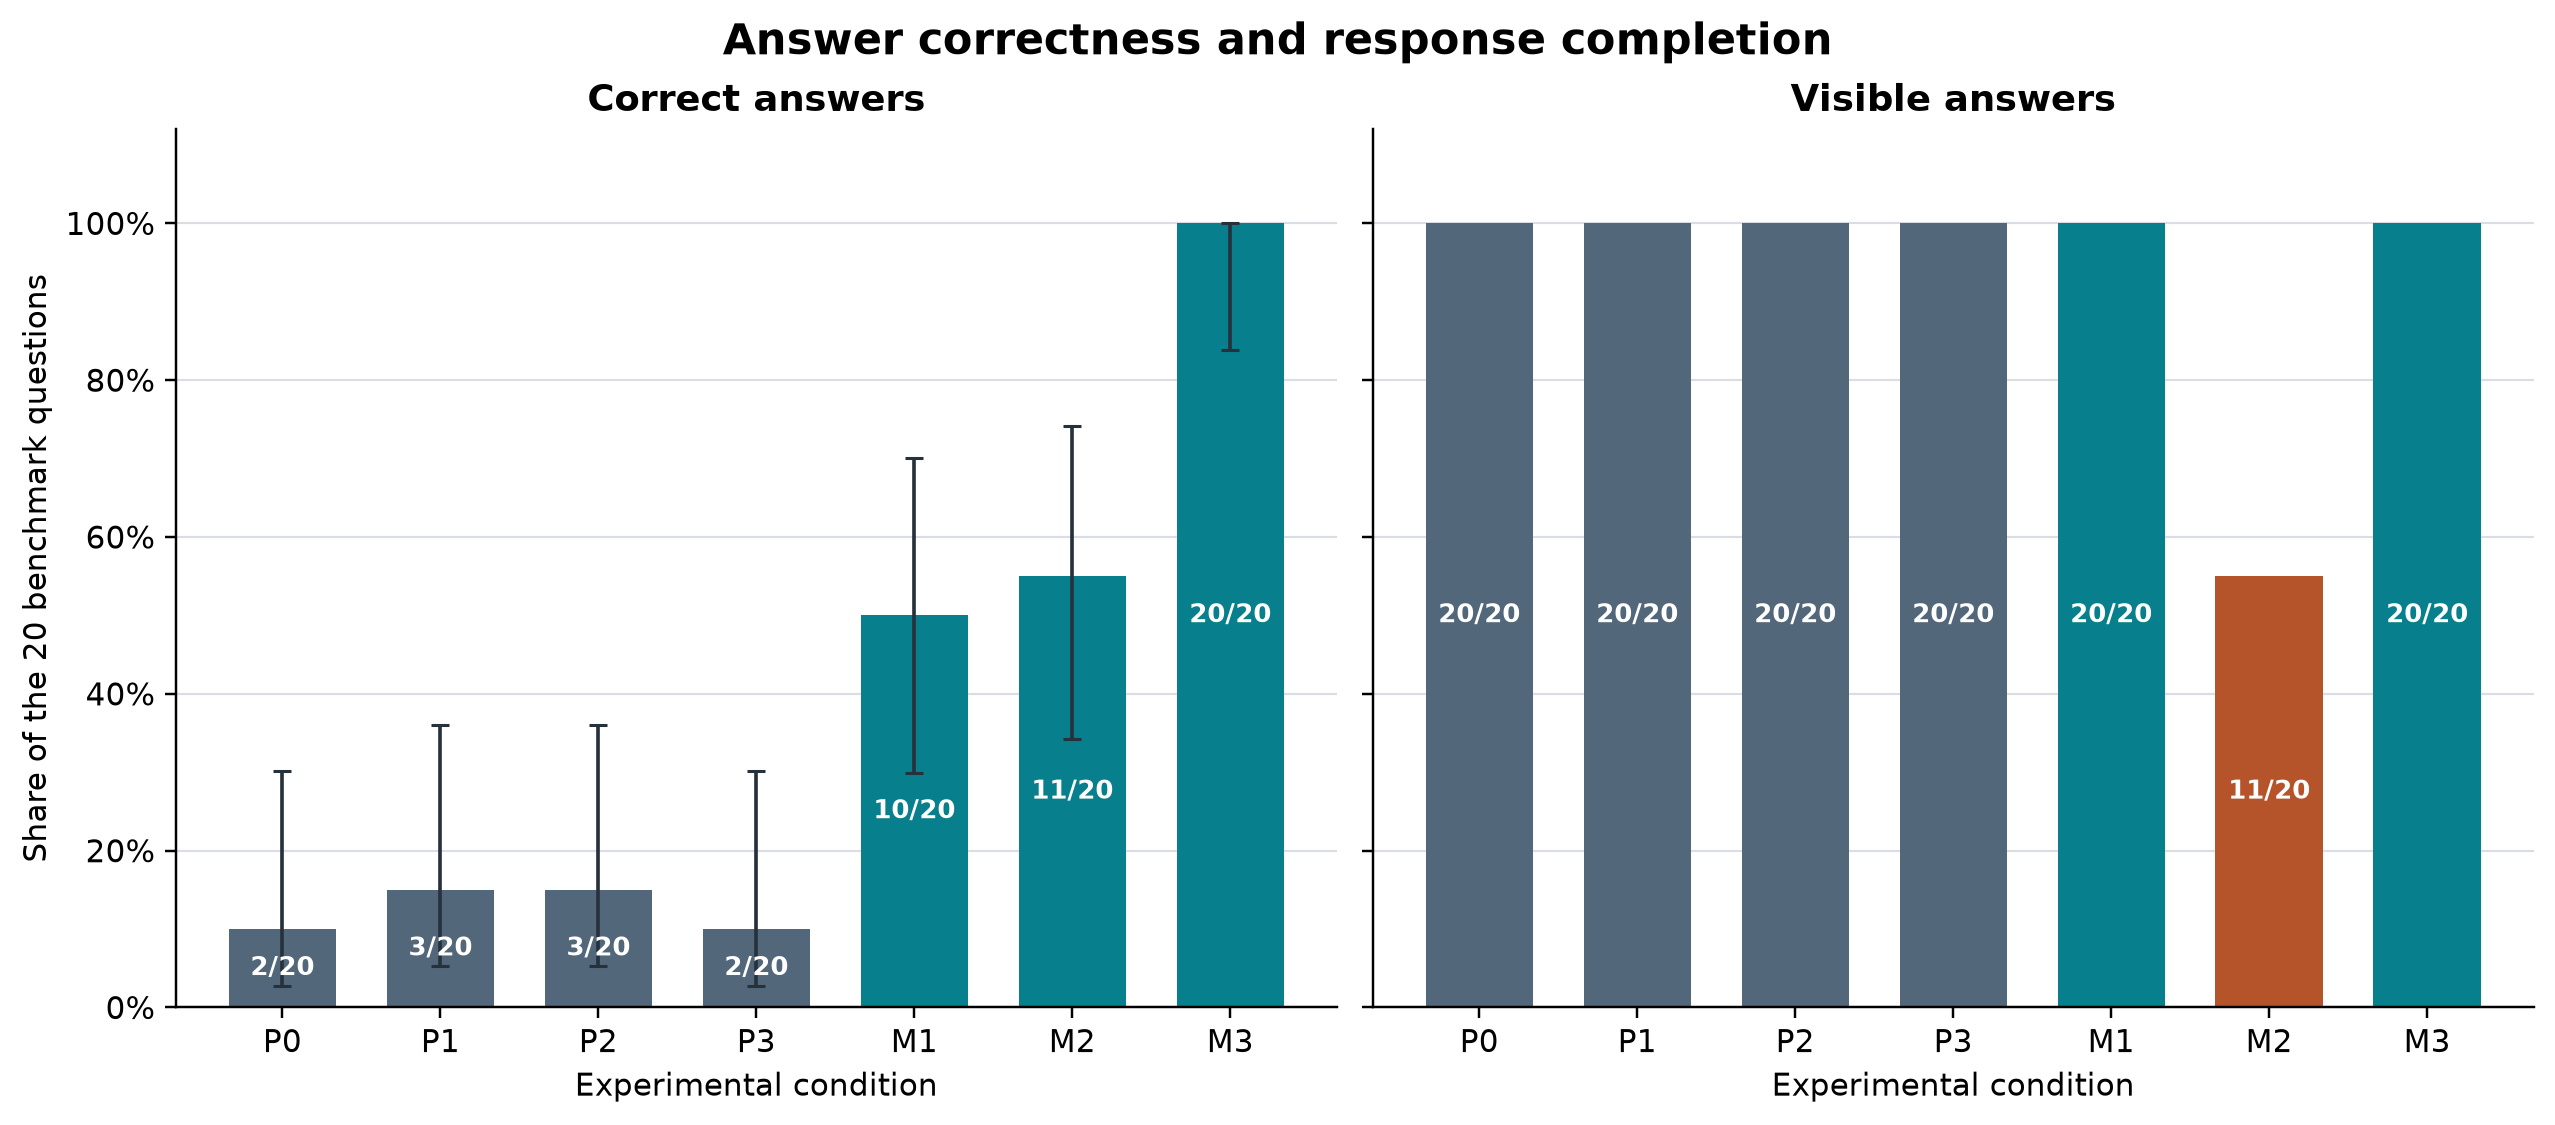

In [2]:
display(Image(data=figures[PROJECT_ROOT / FOLDER / "generation-accuracy-and-completion.png"]))


## 2. Correctness and primary error types

Each vertical stack represents all 20 responses in a condition. We show correct answers alongside one primary category for every incorrect answer. Grounding, conceptual and calculation errors connect with the three categories in Tophel et al. (2025). Deficiency and other make the visible errors complete under our frozen rubric, and `no_visible_answer` records the nine empty M2 answers explicitly. These additions prevent us from comparing category proportions with the paper as if the taxonomies were identical.


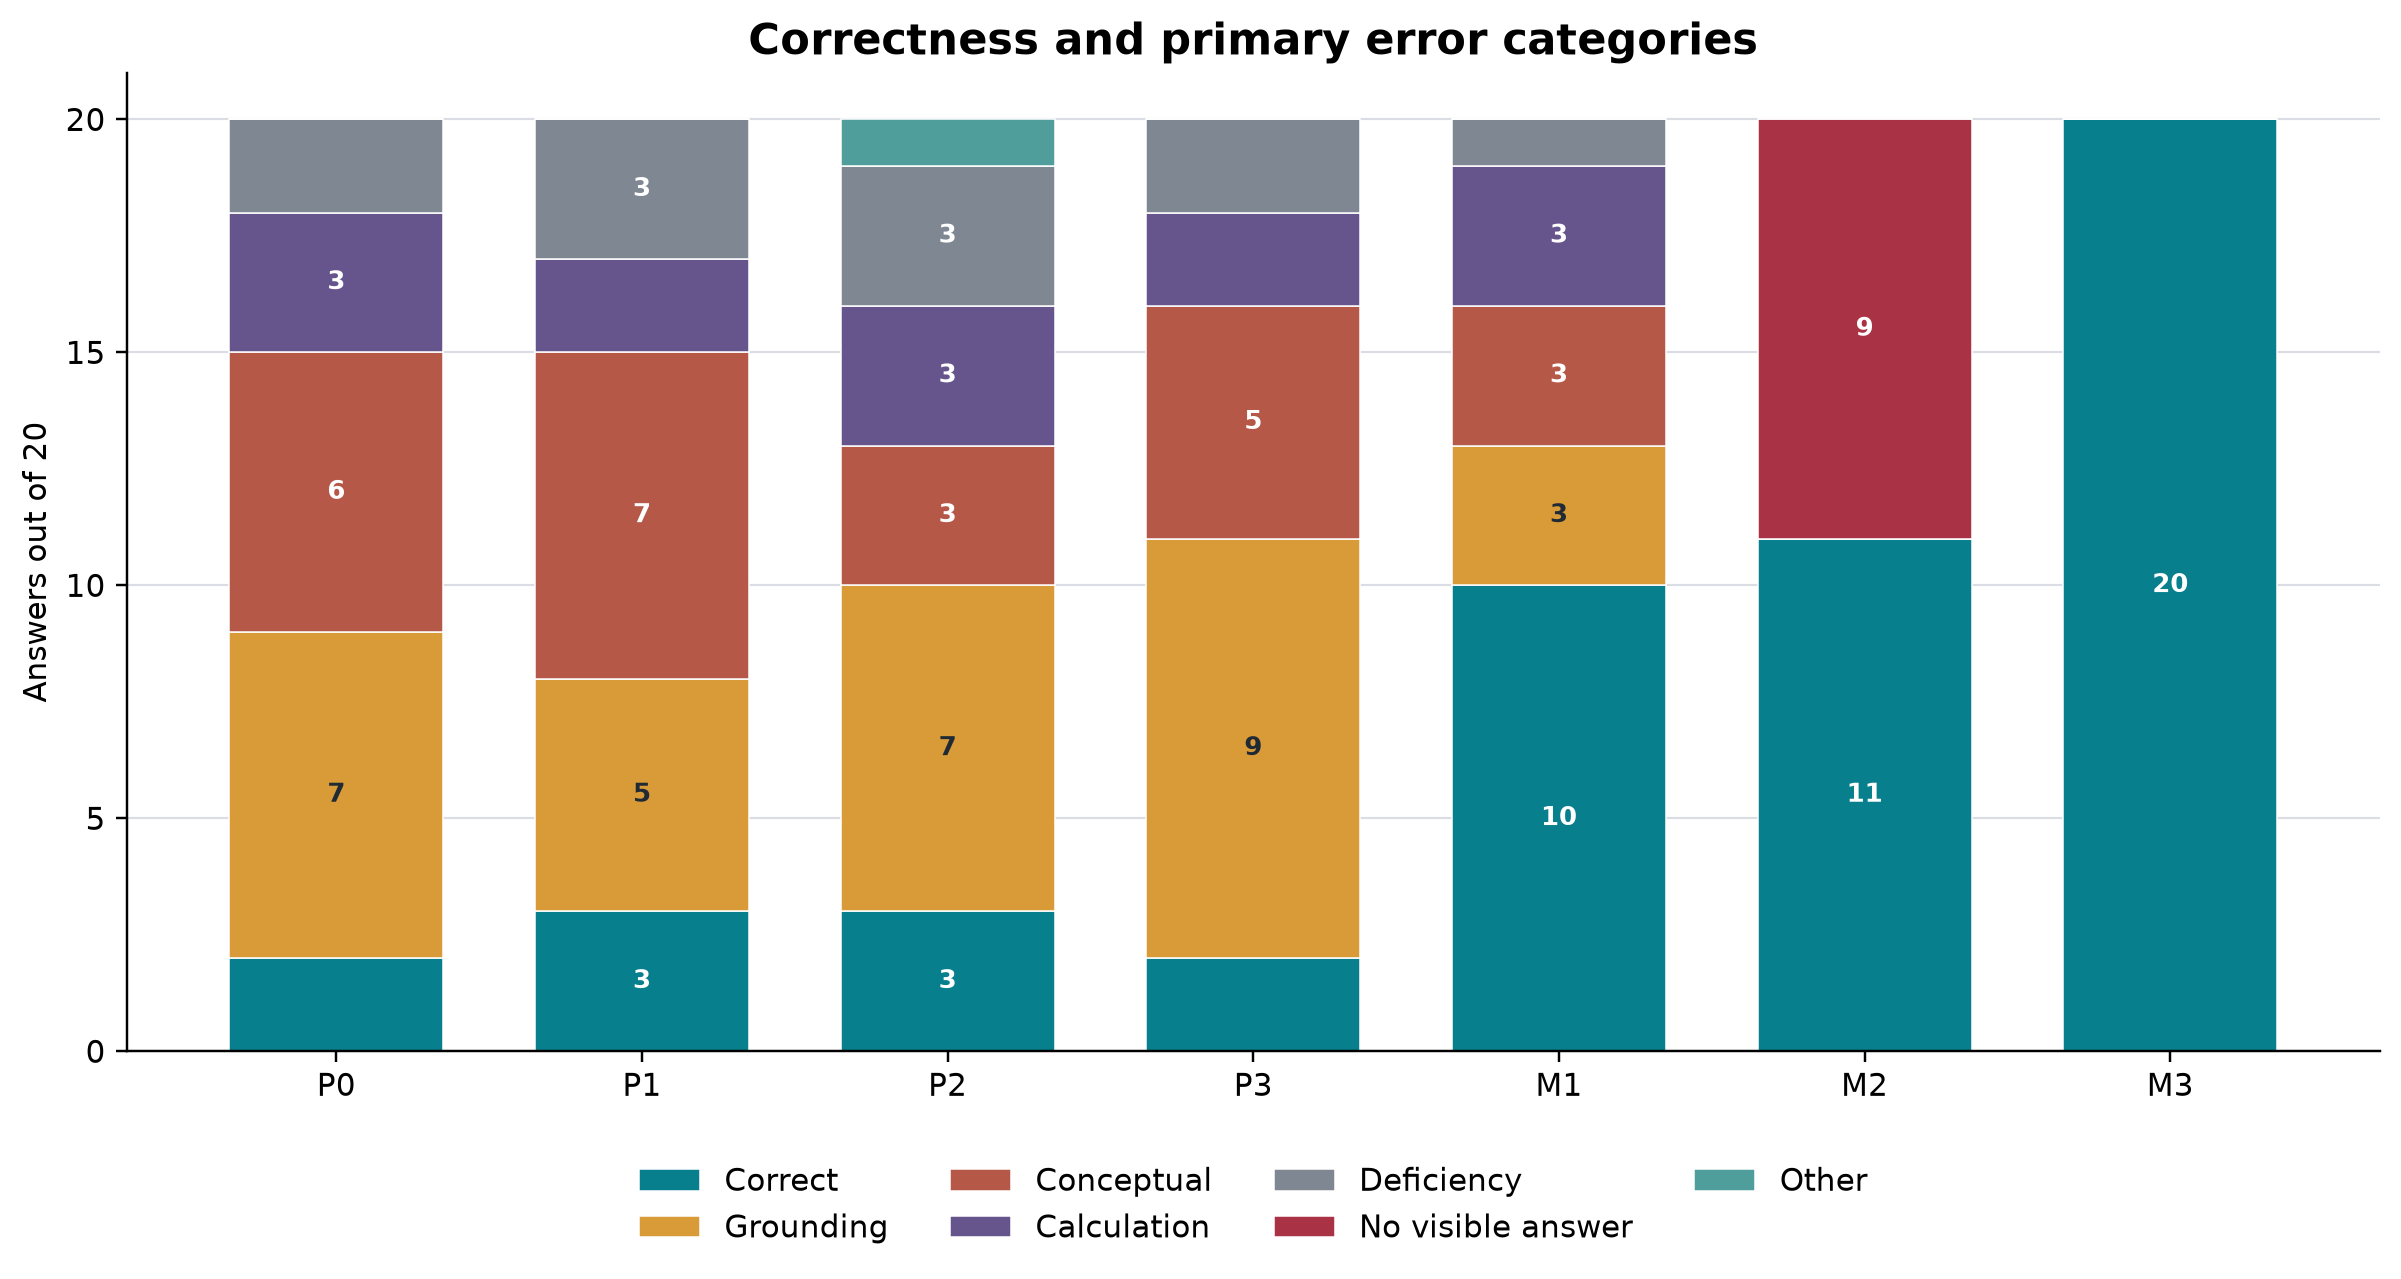

In [3]:
display(Image(data=figures[PROJECT_ROOT / FOLDER / "generation-correctness-and-errors.png"]))


## 3. Secondary evaluation criteria

The heatmap shows means on the frozen 0–2 scoring scale. We keep the applicable denominators in each row: formula integration has 17 questions, calculation correctness 20, unit correctness 18, and clarity and task adaptability 20 each. The nine empty M2 responses receive zero where a criterion applies. This figure is descriptive; the paired Wilcoxon and Friedman results remain in notebook 08 and the metrics file. We do not use a difference in colour alone as a significance test.


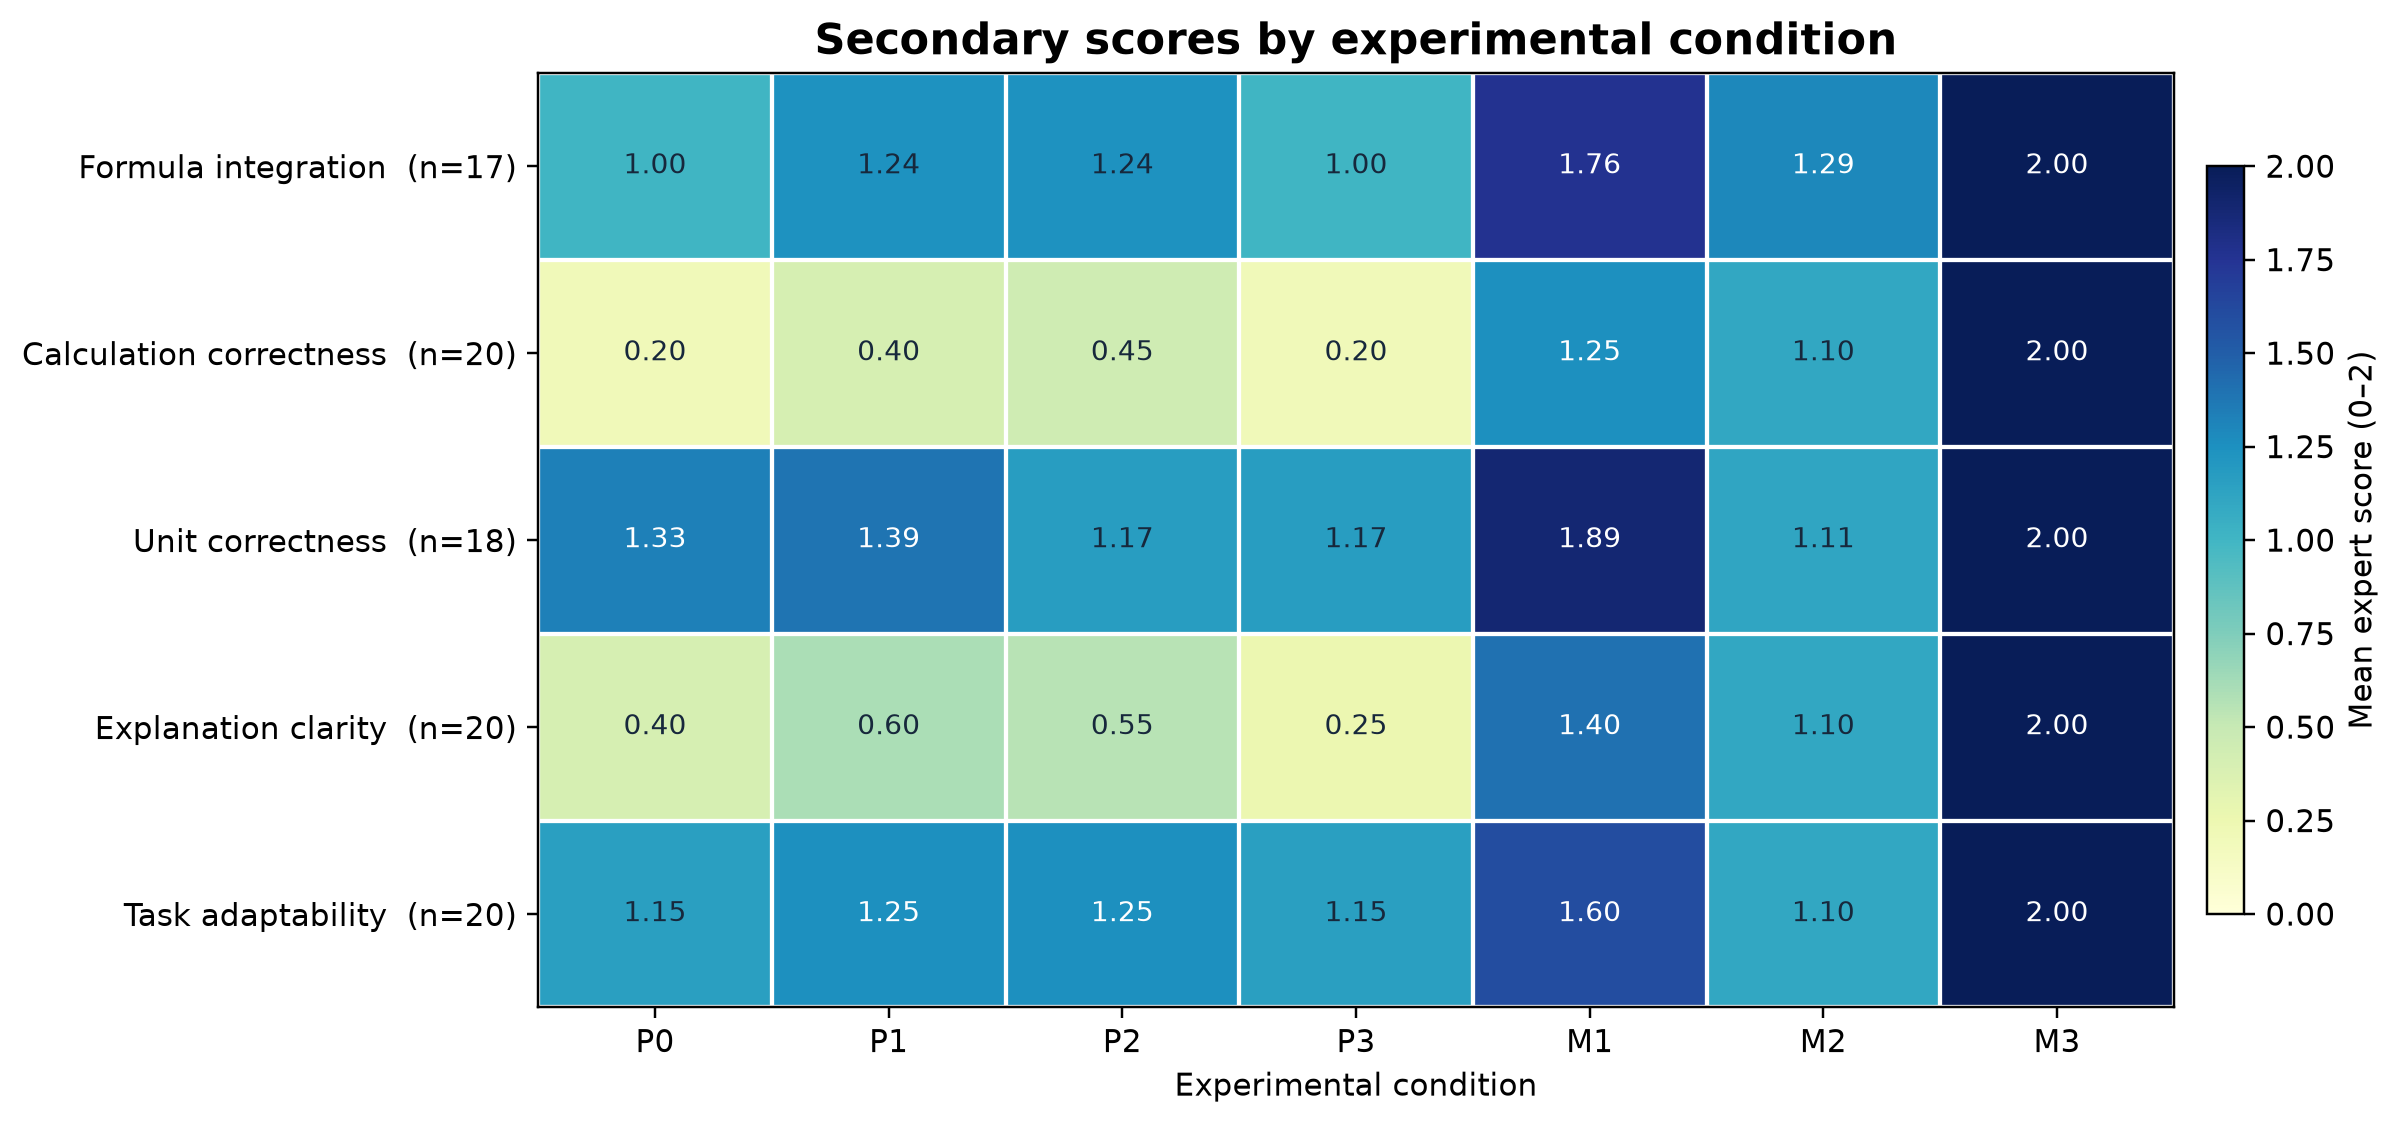

In [4]:
display(Image(data=figures[PROJECT_ROOT / FOLDER / "generation-secondary-scores.png"]))


## 4. Output fingerprints and limits of interpretation

We export each plot as a high-resolution PNG and a vector SVG, with one manifest linking the figures to the five frozen aggregate files and the judgment fingerprint. The write flag starts disabled. The comparison uses one response for each question-condition pair, one domain expert and grouped presentation of seven blinded answers per question. The original paper's reported percentages do not use a fully reconstructable binary correct/20 rule, so we keep any comparison with those percentages descriptive.


In [5]:
for path, content in figures.items():
    print(path.relative_to(PROJECT_ROOT), len(content), hashlib.sha256(content).hexdigest())
if RUN_WRITE_PUBLIC_FIGURES:
    write_figures(figures)
    print("Three PNGs, three SVGs and the manifest saved without overwrite.")
else:
    print("Figure write disabled; preview only.")


results/figures/generation/generation-accuracy-and-completion.png 112654 758b0e42ab5324ba7e67455b343967a5a887c1a26c7098838457a354ade81b80
results/figures/generation/generation-accuracy-and-completion.svg 30925 91b425f3d0246524185647eabcd1de623e69221af91bcf194a43bcde1b8b576d
results/figures/generation/generation-correctness-and-errors.png 84352 770ab258e58b22f63995fba25156ba108fc8fae95e979df047a5d0064571c826
results/figures/generation/generation-correctness-and-errors.svg 35085 b9e39308d6d3a584723be22b446837a621f1a4b5d0fde3613d5751c1e7cc4aa4
results/figures/generation/generation-secondary-scores.png 143963 1c3a0b01cc46acd82b7284b7002db2aa0bc7962679cc66d10303c37bda757ece
results/figures/generation/generation-secondary-scores.svg 36427 e3bee12be4b09ab78488a78f0a6257e742895f707639babf7e983835aeb41255
results/figures/generation/generation-figure-manifest.json 1490 abf08e6995934471275f2c22cd03ba400ba1e72cbc4ad6f838ca588c5aaadbd9
Figure write disabled; preview only.
